In [6]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.line_heuristics.harmony_search import HarmonyLineSearch
from converters.tile.bin_1d import make_1d_bin_palette

from tests.experimental.test_loop import Params, test_loop

FONT_PATH = "../../../../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
ALL_SYMBOLS = get_asciis()
SYMBOLS = [s[len(s) // 2] for s in make_1d_bin_palette(ALL_SYMBOLS, FONT, 9)[0]]
MAX_WIDTH = 30
MAX_HEIGHT = 9
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:10]]

def make_converter(params: Params):
    return HarmonyLineSearch(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        pop_count=30,
        generations=50,
        **params.converter_args)

Min: 0.0522 | Max: 0.2060 | Mean: 0.1287 | Std: 0.0474
Min: 0.0426 | Max: 0.2047 | Mean: 0.1317 | Std: 0.0502
Min: 0.0546 | Max: 0.2023 | Mean: 0.1351 | Std: 0.0534
Min: 0.0572 | Max: 0.1915 | Mean: 0.1336 | Std: 0.0485
Min: 0.0645 | Max: 0.1938 | Mean: 0.1345 | Std: 0.0518


C:\Users\wojte\AppData\Local\Temp\ipykernel_2360\549677722.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


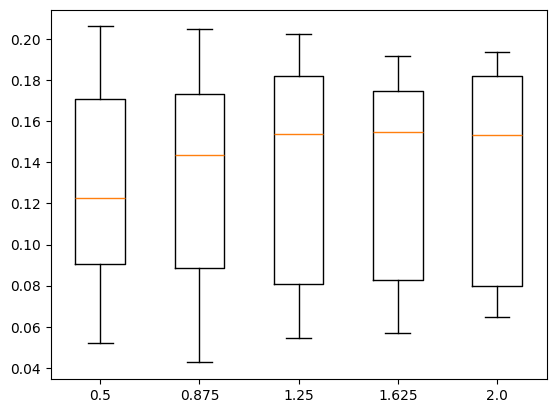

In [7]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [5]:
from PIL import Image
from converters.img_converter import ImgConverter
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = HarmonyLineSearch(symbols=SYMBOLS,
                              font=FONT,
                              pop_count=30,
                              generations=50)

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = ImgConverter(converter).img2symbols(img, None, MAX_WIDTH, MAX_HEIGHT)
    results.append(res_arr)

print_gallery(results, 2)

---------------------------------------------------------
 | -/LNNNNN`NNNDNNNNyNDDLL- | yEDDNENEy^NEENNNNNNDDNNN | 
 | yELLLL/NLyLLLyLE/`^`^``` | yDNLNNNNLLNEDNDNNDDNNNLE | 
 | DDNDEDDNNNNNyDNDDEDLNEND | ``LLNNNDNN/N`^DDNLEEEELy | 
 | NNDNNNNNDNNNND/EDDDDNDNE | yNNNNNEN-`L----DDNyDDDDN | 
 | NDEDNDE-E`/DNNDNDNDNNDDE | DNNNNNNNNE-`EL-NN-ENNNDN | 
 | DNNENEEDyyNyDNNDNNDNNNEN | NyNNDDNNNDL``--DNNNNNN-D | 
 | DNDENNENDNNNEEEyNNDNNNNE | EDNDDDDDNNL--E-ENNDDNNEN | 
 | ENEDDNENENNDNDNNDDNLDNLD | DDNDDENNNDD-`/^E/NENNNNN | 
 | ^NENNENNDNDNDNNDNN^NNL-N | NNNNNDNNNN-/NEN`-///NLND | 
---------------------------------------------------------
 | NNNDNNDEE`ENNNNNyNNNDD^` | -`````````` | 
 | EEDNNL/NLDDNDDNNL/`-```` | LLLLLLLLLLy | 
 | NyDNNDyDEDDLDNDNDLDDEDLL | NNNNNNNDNND | 
 | DDNL`EENENNNNNNNLENNDNDE | NNNNNNNNDNE | 
 | NENNE^NNN/NNNNDDNNDD`D-D | NNNN^N`NNNN | 
 | NDNNNN```^EEENNENDEyLD-` | NNNN```/NND | 
 | DDDNND`DD/-`-^`L-`-````N | NNNN`L-`NNN | 
 | D`ED/N--`LD`/`-`yDNNNNND | NNNNDDDLNND | 
 |